# Notebook 04: HVAC Fault Detection Model

**Module C** of the smart-facility-pulse pilot.

This notebook builds the machine learning model that powers the Predictive Maintenance page of the dashboard.

**Pipeline:**
1. Load processed LBNL FCU data
2. Filter to occupied hours (when faults are observable)
3. Engineer features (rolling stats, lags, ratios)
4. Train/test split (time-aware, no data leakage)
5. Train XGBoost binary fault classifier
6. Evaluate (ROC-AUC, precision, recall, confusion matrix)
7. SHAP explainability
8. Save model artifacts for Streamlit

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost shap

import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score)
import joblib

PROJECT_ROOT = '/content/drive/MyDrive/smart-facility-pulse'
LBNL_DIR = os.path.join(PROJECT_ROOT, 'data', 'lbnl')
MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
np.random.seed(42)

print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"Model directory: {MODEL_DIR}")

Mounted at /content/drive
XGBoost version: 3.2.0
SHAP version: 0.51.0
Model directory: /content/drive/MyDrive/smart-facility-pulse/models


In [3]:
fcu_df = pd.read_parquet(os.path.join(LBNL_DIR, 'fcu_processed.parquet'))

fcu_df = fcu_df.sort_values(['fault_type', 'severity', 'Datetime']).reset_index(drop=True)

print(f"✓ Loaded: {fcu_df.shape}")
print(f"✓ Time range: {fcu_df['Datetime'].min()} → {fcu_df['Datetime'].max()}")
print(f"✓ Fault label split: {fcu_df['fault_label'].value_counts().to_dict()}")
fcu_df.head(3)

✓ Loaded: (157680, 27)
✓ Time range: 2018-01-01 00:00:00 → 2018-12-31 23:00:00
✓ Fault label split: {1: 148920, 0: 8760}


,Datetime,FCU_CTRL,FAN_CTRL,RM_TEMP,RMCLGSPT,FCU_MAT,FCU_DAT,FCU_RAT,FCU_CVLV,FCU_CVLV_DM,...,FCU_SPD,FCU_OAT,FCU_WAT,FCU_MA_HUMD,FCU_OA_HUMD,FCU_DA_HUMD,FCU_RA_HUMD,fault_label,fault_type,severity
0,2018-01-01 00:00:00,2.0,1.0,22.22,29.44,9.42,19.90,22.22,0.987,0.0,...,0.0,-3.38,0.0,20.672,56.362,51.261,9.079,1,control_reverse,na
1,2018-01-01 01:00:00,2.0,1.0,21.79,29.44,9.37,14.74,21.79,1.000,0.0,...,0.0,-3.06,0.0,20.878,55.020,70.769,9.318,1,control_reverse,na
2,2018-01-01 02:00:00,2.0,1.0,21.60,29.44,9.41,11.68,21.60,1.000,0.0,...,0.0,-2.78,0.0,20.958,53.930,85.989,9.440,1,control_reverse,na


In [4]:
# LBNL schedule: Mon-Fri 6am-6pm = Operate Mode (FCU_CTRL = 1)
# Filter to rows where the FCU is actually running
fcu_df['hour'] = fcu_df['Datetime'].dt.hour
fcu_df['dayofweek'] = fcu_df['Datetime'].dt.dayofweek  # 0=Mon, 6=Sun
fcu_df['is_weekday'] = (fcu_df['dayofweek'] < 5).astype(int)
fcu_df['is_occupied'] = ((fcu_df['hour'] >= 6) & (fcu_df['hour'] < 18) &
                         (fcu_df['is_weekday'] == 1)).astype(int)

before_filter = len(fcu_df)
fcu_active = fcu_df[fcu_df['is_occupied'] == 1].copy().reset_index(drop=True)
after_filter = len(fcu_active)

print(f"Before filter: {before_filter:,} rows")
print(f"After filter:  {after_filter:,} rows ({after_filter/before_filter*100:.1f}% retained)")
print(f"\nLabel split after filter:")
print(fcu_active['fault_label'].value_counts())
print(f"\nClass balance: {fcu_active['fault_label'].mean()*100:.1f}% faulty")

Before filter: 157,680 rows
After filter:  56,376 rows (35.8% retained)

Label split after filter:
fault_label
1    53244
0     3132
Name: count, dtype: int64

Class balance: 94.4% faulty


In [5]:
def engineer_features(df):
    """Add rolling stats, derived ratios, and deltas. Critical FM signals."""
    df = df.copy()
    # Group features by fault scenario so rolling windows don't leak across files
    group_keys = ['fault_type', 'severity']

    # ---------- Group 1: Derived efficiency / physics features ----------
    # How hard the system is working
    df['cooling_load_proxy'] = df['FCU_OAT'] - df['RM_TEMP']  # outdoor-indoor delta
    df['supply_temp_delta'] = df['FCU_RAT'] - df['FCU_DAT']    # how much it's cooling
    df['chw_temp_delta'] = df['FCU_CLG_RWT'] - df['FCU_CLG_EWT']  # chilled water Δ

    # Efficiency proxies
    df['airflow_per_valve_open'] = df['FCU_DA_CFM'] / (df['FCU_CVLV'] + 0.01)
    df['fan_power_per_cfm'] = df['FCU_WAT'] / (df['FCU_DA_CFM'] + 0.1)
    df['valve_command_error'] = (df['FCU_CVLV'] - df['FCU_CVLV_DM']).abs()

    # Setpoint tracking
    df['temp_above_setpoint'] = df['RM_TEMP'] - df['RMCLGSPT']

    # ---------- Group 2: Rolling stats (capture trends) ----------
    rolling_features = ['RM_TEMP', 'FCU_DA_CFM', 'FCU_WAT', 'FCU_CVLV',
                        'supply_temp_delta', 'temp_above_setpoint']
    for col in rolling_features:
        # 6-hour rolling mean and std (within same scenario only)
        df[f'{col}_roll6_mean'] = df.groupby(group_keys)[col].transform(
            lambda x: x.rolling(window=6, min_periods=1).mean())
        df[f'{col}_roll6_std'] = df.groupby(group_keys)[col].transform(
            lambda x: x.rolling(window=6, min_periods=1).std().fillna(0))

    # ---------- Group 3: Lag features ----------
    for col in ['RM_TEMP', 'FCU_DA_CFM', 'FCU_WAT']:
        df[f'{col}_lag1'] = df.groupby(group_keys)[col].shift(1).fillna(method='bfill')
        df[f'{col}_delta'] = df[col] - df[f'{col}_lag1']

    return df

print("Engineering features...")
fcu_feat = engineer_features(fcu_active)

# Identify feature columns (exclude metadata + target)
META_COLS = ['Datetime', 'fault_type', 'severity', 'fault_label',
             'hour', 'dayofweek', 'is_weekday', 'is_occupied']
FEATURE_COLS = [c for c in fcu_feat.columns if c not in META_COLS]

print(f"✓ Total features: {len(FEATURE_COLS)}")
print(f"✓ Final shape: {fcu_feat.shape}")
print(f"\nFeature categories:")
print(f"   • Raw sensors: 23")
print(f"   • Derived (efficiency/physics): 7")
print(f"   • Rolling stats (mean/std): 12")
print(f"   • Lag/delta: 6")

Engineering features...
✓ Total features: 48
✓ Final shape: (56376, 56)

Feature categories:
   • Raw sensors: 23
   • Derived (efficiency/physics): 7
   • Rolling stats (mean/std): 12
   • Lag/delta: 6


In [6]:
# Time-based split: train on Jan-Sep, test on Oct-Dec
SPLIT_DATE = pd.Timestamp('2018-10-01')

train_mask = fcu_feat['Datetime'] < SPLIT_DATE
test_mask = fcu_feat['Datetime'] >= SPLIT_DATE

X_train = fcu_feat.loc[train_mask, FEATURE_COLS]
y_train = fcu_feat.loc[train_mask, 'fault_label']
X_test = fcu_feat.loc[test_mask, FEATURE_COLS]
y_test = fcu_feat.loc[test_mask, 'fault_label']

# Also keep test metadata for later analysis
test_meta = fcu_feat.loc[test_mask, ['Datetime', 'fault_type', 'severity']].reset_index(drop=True)

print(f"Train set: {X_train.shape} | Faulty rate: {y_train.mean()*100:.1f}%")
print(f"Test set:  {X_test.shape} | Faulty rate: {y_test.mean()*100:.1f}%")
print(f"\nTrain time range: {fcu_feat.loc[train_mask, 'Datetime'].min()} → {fcu_feat.loc[train_mask, 'Datetime'].max()}")
print(f"Test  time range: {fcu_feat.loc[test_mask, 'Datetime'].min()} → {fcu_feat.loc[test_mask, 'Datetime'].max()}")

Train set: (42120, 48) | Faulty rate: 94.4%
Test set:  (14256, 48) | Faulty rate: 94.4%

Train time range: 2018-01-01 06:00:00 → 2018-09-28 17:00:00
Test  time range: 2018-10-01 06:00:00 → 2018-12-31 17:00:00


In [7]:
# Class imbalance is ~95% faulty / 5% healthy → adjust scale_pos_weight inversely
# We want to predict FAULT (positive class = 1)
# Since faulty is the majority, scale_pos_weight = healthy/faulty < 1
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Computed scale_pos_weight: {scale_pos_weight:.3f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    tree_method='hist',     # fast histogram-based training
    random_state=42,
    n_jobs=-1,
)

print("Training XGBoost...")
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=50)

print("\n✓ Training complete.")

Computed scale_pos_weight: 0.059
Training XGBoost...
[0]	validation_0-auc:0.99103	validation_1-auc:0.97636
[50]	validation_0-auc:0.99943	validation_1-auc:0.99579
[100]	validation_0-auc:0.99972	validation_1-auc:0.99684
[150]	validation_0-auc:0.99985	validation_1-auc:0.99714
[200]	validation_0-auc:0.99991	validation_1-auc:0.99729
[250]	validation_0-auc:0.99994	validation_1-auc:0.99731
[299]	validation_0-auc:0.99997	validation_1-auc:0.99731

✓ Training complete.


MODEL PERFORMANCE ON HOLDOUT TEST SET

ROC-AUC: 0.9973

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.76      0.95      0.84       792
      Faulty       1.00      0.98      0.99     13464

    accuracy                           0.98     14256
   macro avg       0.88      0.97      0.92     14256
weighted avg       0.98      0.98      0.98     14256



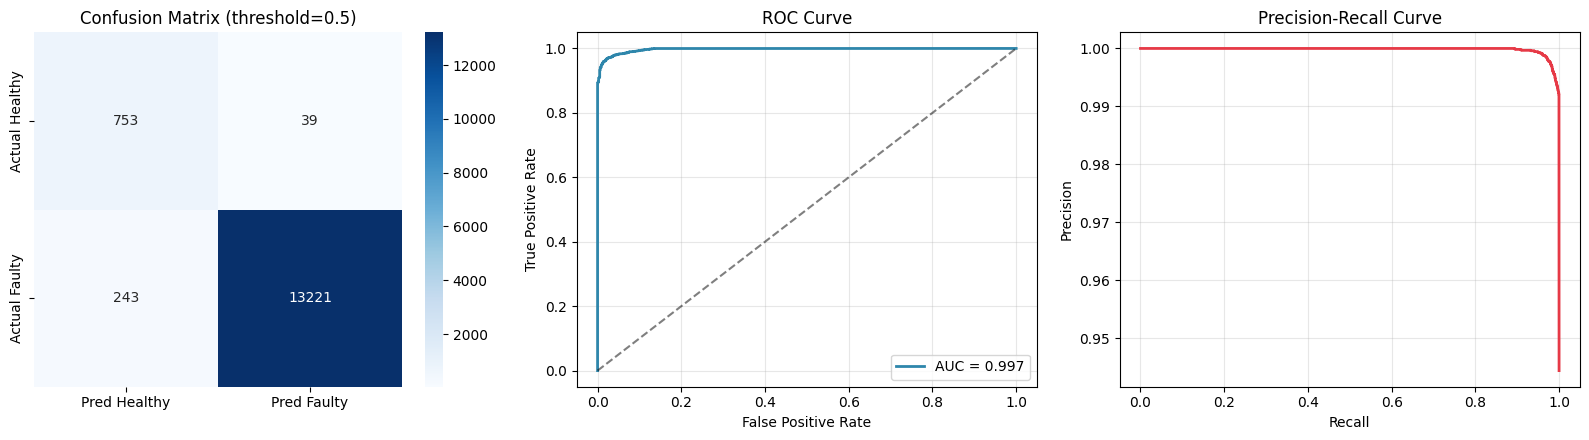

In [8]:
# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
auc = roc_auc_score(y_test, y_pred_proba)
print("=" * 60)
print("MODEL PERFORMANCE ON HOLDOUT TEST SET")
print("=" * 60)
print(f"\nROC-AUC: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Faulty']))

# Confusion matrix + ROC + PR curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Healthy', 'Pred Faulty'],
            yticklabels=['Actual Healthy', 'Actual Faulty'], ax=axes[0])
axes[0].set_title('Confusion Matrix (threshold=0.5)')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2E86AB', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(rec, prec, color='#E63946', linewidth=2)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [9]:
test_results = test_meta.copy()
test_results['actual'] = y_test.values
test_results['predicted'] = y_pred
test_results['fault_proba'] = y_pred_proba

# Per fault-type accuracy
print("=" * 75)
print("DETECTION RATE BY FAULT TYPE (Test Set)")
print("=" * 75)
breakdown = (test_results.groupby(['fault_type', 'severity'])
             .agg(rows=('actual', 'size'),
                  detection_rate=('predicted', lambda x: x.mean() if x.iloc[0] is not None else 0),
                  avg_fault_proba=('fault_proba', 'mean'))
             .reset_index())

# For healthy, "detection_rate" doesn't apply — replace with FPR
def _detection(row):
    sub = test_results[(test_results['fault_type'] == row['fault_type']) &
                       (test_results['severity'] == row['severity'])]
    if sub['actual'].iloc[0] == 0:
        return 1 - sub['predicted'].mean()  # specificity
    return sub['predicted'].mean()  # sensitivity

breakdown['correct_rate'] = breakdown.apply(_detection, axis=1)
breakdown_display = breakdown[['fault_type', 'severity', 'rows', 'correct_rate', 'avg_fault_proba']]
breakdown_display.columns = ['Fault Type', 'Severity', 'Rows', 'Correct %', 'Avg Fault Score']
breakdown_display['Correct %'] = (breakdown_display['Correct %'] * 100).round(1)
breakdown_display['Avg Fault Score'] = breakdown_display['Avg Fault Score'].round(3)
print(breakdown_display.to_string(index=False))

DETECTION RATE BY FAULT TYPE (Test Set)
               Fault Type Severity  Rows  Correct %  Avg Fault Score
          control_reverse       na   792      100.0            0.999
         control_unstable       na   792       99.7            0.989
  cooling_fouling_airside    minor   792       98.6            0.979
  cooling_fouling_airside moderate   792      100.0            0.997
  cooling_fouling_airside   severe   792      100.0            1.000
cooling_fouling_waterside    minor   792       92.4            0.922
cooling_fouling_waterside moderate   792       92.3            0.923
cooling_fouling_waterside   severe   792       91.9            0.920
       cooling_valve_leak moderate   792      100.0            0.999
      cooling_valve_stuck   closed   792       94.3            0.944
      cooling_valve_stuck     open   792      100.0            0.999
      fan_outlet_blockage   severe   792      100.0            0.999
               fault_free     none   792       95.1            

Computing SHAP values (this takes ~30s)...
✓ SHAP computed on 5000 samples


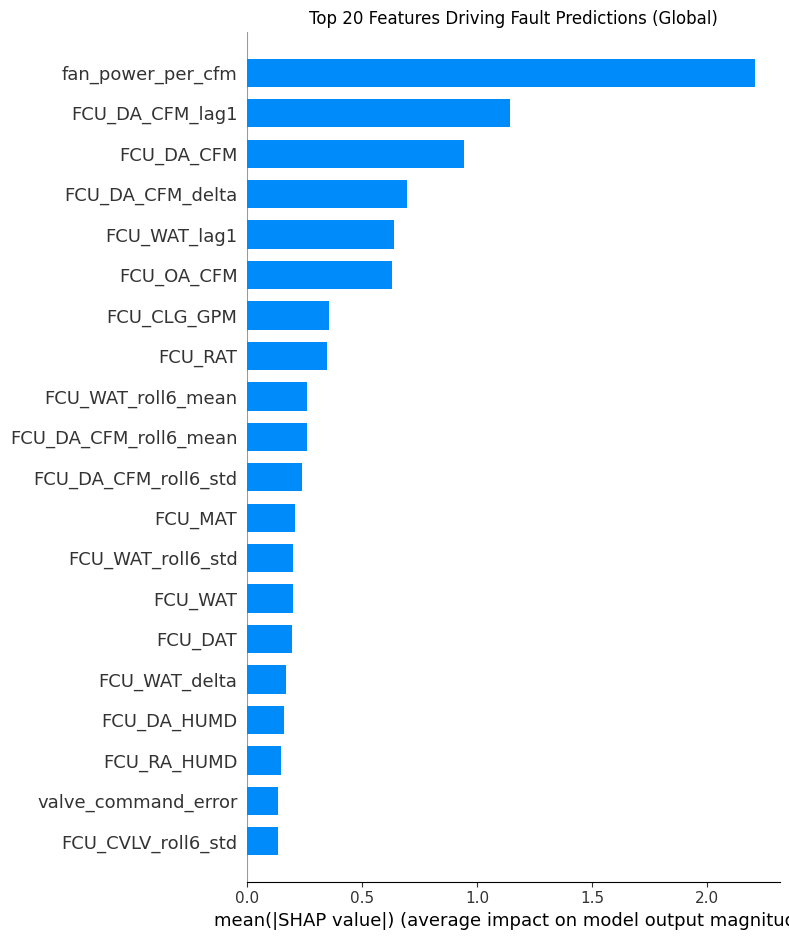

In [10]:
print("Computing SHAP values (this takes ~30s)...")

# Sample to keep SHAP computation fast (5,000 random test rows)
sample_size = min(5000, len(X_test))
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"✓ SHAP computed on {sample_size} samples")

# Global feature importance via SHAP
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  max_display=20, show=False)
plt.title('Top 20 Features Driving Fault Predictions (Global)', fontsize=12)
plt.tight_layout(); plt.show()

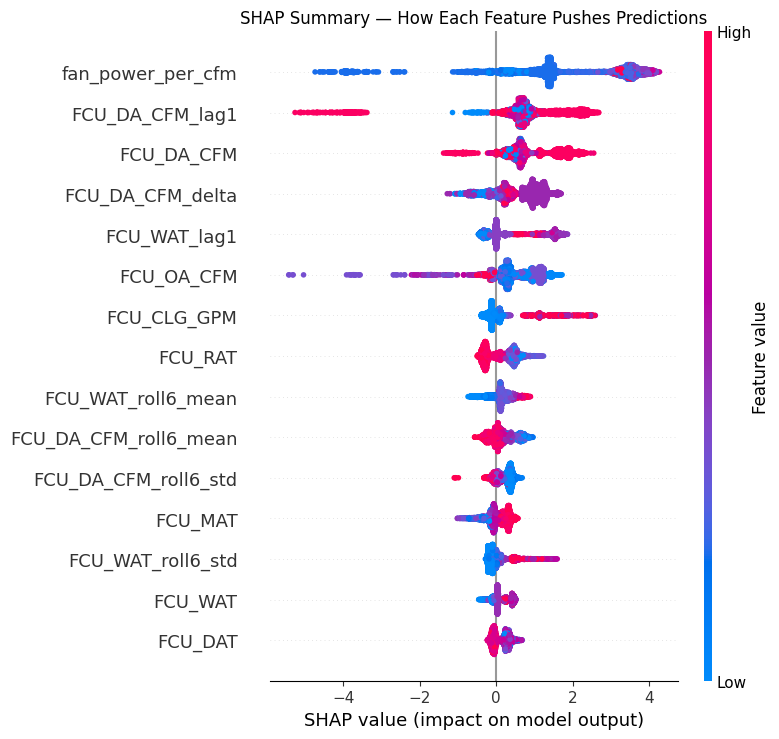

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Summary — How Each Feature Pushes Predictions', fontsize=12)
plt.tight_layout(); plt.show()

Example: control_reverse (na) on 2018-10-01 06:00:00
Predicted fault probability: 1.000


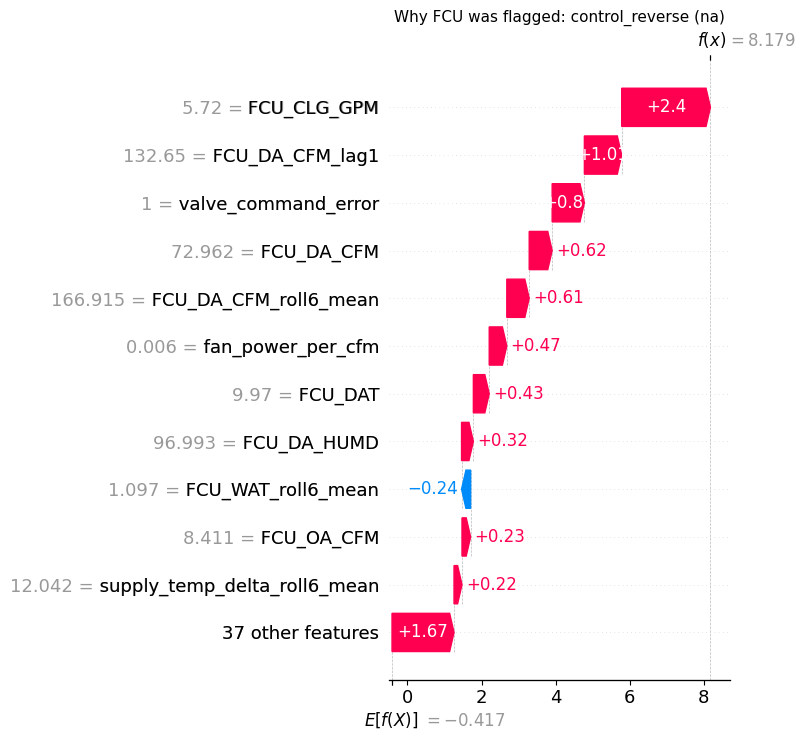

In [12]:
# Pick a clearly faulty test sample with high fault probability
faulty_test_idx = np.where((y_test.values == 1) & (y_pred_proba > 0.95))[0]
example_idx = faulty_test_idx[0]
example_meta = test_meta.iloc[example_idx]

print(f"Example: {example_meta['fault_type']} ({example_meta['severity']}) "
      f"on {example_meta['Datetime']}")
print(f"Predicted fault probability: {y_pred_proba[example_idx]:.3f}")

# Waterfall plot — the explanation an FM tech would see
shap_vals_single = explainer.shap_values(X_test.iloc[[example_idx]])
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_single[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[example_idx].values,
    feature_names=FEATURE_COLS
), max_display=12, show=False)
plt.title(f"Why FCU was flagged: {example_meta['fault_type']} ({example_meta['severity']})",
          fontsize=11)
plt.tight_layout(); plt.show()

In [13]:
# Save model
model_path = os.path.join(MODEL_DIR, 'hvac_fault_xgb.pkl')
joblib.dump(model, model_path)

# Save feature column list (Streamlit needs to know feature order)
features_path = os.path.join(MODEL_DIR, 'feature_columns.pkl')
joblib.dump(FEATURE_COLS, features_path)

# Save the SHAP explainer base value (for waterfall plots in Streamlit)
shap_meta_path = os.path.join(MODEL_DIR, 'shap_base_value.pkl')
joblib.dump(float(explainer.expected_value), shap_meta_path)

# Save a sample of scored test data — so the dashboard has something to display immediately
dashboard_sample = test_results.copy()
dashboard_sample = dashboard_sample.merge(
    fcu_feat.loc[test_mask, FEATURE_COLS].reset_index(drop=True),
    left_index=True, right_index=True
)
dashboard_sample_path = os.path.join(MODEL_DIR, 'scored_test_sample.parquet')
dashboard_sample.to_parquet(dashboard_sample_path, index=False)

print("=" * 60)
print("✓ ARTIFACTS SAVED")
print("=" * 60)
for p in [model_path, features_path, shap_meta_path, dashboard_sample_path]:
    size_kb = os.path.getsize(p) / 1024
    print(f"   {os.path.basename(p):<35} {size_kb:>8.1f} KB")

print(f"   Test AUC: {auc:.4f}")

✓ ARTIFACTS SAVED
   hvac_fault_xgb.pkl                     567.0 KB
   feature_columns.pkl                      0.8 KB
   shap_base_value.pkl                      0.0 KB
   scored_test_sample.parquet            1805.7 KB

✓ Module C model complete.
   Test AUC: 0.9973
   Model ready for Streamlit dashboard integration.
